In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/moved/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/README.txt
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/meta_data.csv
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/desktop.ini
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2/FakeVideo-FakeAudio/African/men/id00391/00052_id00173_wavtolip.mp4
/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/F

In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [4]:
print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [6]:
import os
print(os.listdir("/kaggle/input/datasets"))

['shreyaty08']


In [7]:
import os
print(os.listdir("/kaggle/input/datasets/shreyaty08"))

['fakeavceleb']


In [8]:
import os

print(os.listdir("/kaggle/input/datasets/shreyaty08/fakeavceleb"))

['FakeAVCeleb_v1.2']


In [9]:
import os

print(os.listdir("/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2"))

['moved', 'FakeAVCeleb_v1.2', 'frames', 'desktop.ini']


In [10]:
import os

frames_path = "/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/frames"

print(os.listdir(frames_path))

['FakeVideo-FakeAudio', 'FakeVideo-RealAudio', 'desktop.ini', 'RealVideo-RealAudio', 'RealVideo-FakeAudio']


In [11]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
GPU: Tesla T4


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from pathlib import Path
import os
import random
import numpy as np

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
CUDA: True


In [13]:
from pathlib import Path
import random

frames_root = Path(
    "/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/frames"
)

real_folders = ["RealVideo-RealAudio", "RealVideo-FakeAudio"]
fake_folders = ["FakeVideo-RealAudio", "FakeVideo-FakeAudio"]

def get_source_folders(folder_names):
    folders = set()

    for folder_name in folder_names:
        root = frames_root / folder_name

        for image_path in root.rglob("*.jpg"):
            folders.add(image_path.parent)

    return list(folders)

real_sources = get_source_folders(real_folders)
fake_sources = get_source_folders(fake_folders)

print("REAL source folders:", len(real_sources))
print("FAKE source folders:", len(fake_sources))

REAL source folders: 1000
FAKE source folders: 999


In [14]:
random.seed(42)

# Use equal numbers from both classes
n = min(len(real_sources), len(fake_sources))

real_sources = real_sources[:n]
fake_sources = fake_sources[:n]

random.shuffle(real_sources)
random.shuffle(fake_sources)

def split_sources(sources):
    n_total = len(sources)

    n_train = int(0.70 * n_total)
    n_val = int(0.15 * n_total)

    train = sources[:n_train]
    val = sources[n_train:n_train + n_val]
    test = sources[n_train + n_val:]

    return train, val, test

real_train, real_val, real_test = split_sources(real_sources)
fake_train, fake_val, fake_test = split_sources(fake_sources)

print("REAL:")
print("Train:", len(real_train))
print("Validation:", len(real_val))
print("Test:", len(real_test))

print("\nFAKE:")
print("Train:", len(fake_train))
print("Validation:", len(fake_val))
print("Test:", len(fake_test))

REAL:
Train: 699
Validation: 149
Test: 151

FAKE:
Train: 699
Validation: 149
Test: 151


In [15]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms ready!")

Transforms ready!


In [16]:
class FakeAVCelebFrameDataset(Dataset):
    def __init__(self, source_folders, label, transform=None):
        self.samples = []
        self.transform = transform

        for folder in source_folders:
            for image_path in folder.glob("*.jpg"):
                self.samples.append((image_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Labels:
# FAKE = 0
# REAL = 1

train_dataset = torch.utils.data.ConcatDataset([
    FakeAVCelebFrameDataset(fake_train, 0, train_transform),
    FakeAVCelebFrameDataset(real_train, 1, train_transform)
])

val_dataset = torch.utils.data.ConcatDataset([
    FakeAVCelebFrameDataset(fake_val, 0, val_transform),
    FakeAVCelebFrameDataset(real_val, 1, val_transform)
])

test_dataset = torch.utils.data.ConcatDataset([
    FakeAVCelebFrameDataset(fake_test, 0, val_transform),
    FakeAVCelebFrameDataset(real_test, 1, val_transform)
])

print("Training frames:", len(train_dataset))
print("Validation frames:", len(val_dataset))
print("Test frames:", len(test_dataset))

Training frames: 15119
Validation frames: 3206
Test frames: 3234


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Replace the original classifier with 2 classes:
# 0 = FAKE
# 1 = REAL
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    2
)

model = model.to(device)

print("Model: EfficientNet-B0")
print("Device:", device)
print("Classes: FAKE, REAL")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


Model: EfficientNet-B0
Device: cuda
Classes: FAKE, REAL


In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.0001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.0001


In [19]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders ready!")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders ready!
Training batches: 473
Validation batches: 101
Test batches: 102


In [ ]:
import time

num_epochs = 30

best_val_acc = 0.0
best_model_path = "/kaggle/working/FINAL_EfficientNet_B0_FakeAVCeleb.pth"

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    start_time = time.time()

    # --------------------
    # TRAINING
    # --------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    # --------------------
    # VALIDATION
    # --------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

    elapsed = (time.time() - start_time) / 60

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc*100:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc*100:.2f}% "
        f"| Time: {elapsed:.1f} min"
    )

print("\nTRAINING FINISHED")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Model saved to: {best_model_path}")

In [22]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load the saved best model
model.load_state_dict(
    torch.load(
        "/kaggle/working/FINAL_EfficientNet_B0_FakeAVCeleb.pth",
        map_location=device
    )
)

model.eval()

all_labels = []
all_predictions = []

print("Testing started...")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

print("Testing finished!")

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, zero_division=0)
recall = recall_score(all_labels, all_predictions, zero_division=0)
f1 = f1_score(all_labels, all_predictions, zero_division=0)

print("\n===== TEST RESULTS =====")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score : {f1:.4f} ({f1*100:.2f}%)")

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_predictions))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=["FAKE", "REAL"],
    zero_division=0
))

Testing started...
Testing finished!

===== TEST RESULTS =====
Accuracy : 0.9975 (99.75%)
Precision: 0.9735 (97.35%)
Recall   : 0.9735 (97.35%)
F1 Score : 0.9735 (97.35%)

Confusion Matrix:
[[3079    4]
 [   4  147]]

Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      3083
        REAL       0.97      0.97      0.97       151

    accuracy                           1.00      3234
   macro avg       0.99      0.99      0.99      3234
weighted avg       1.00      1.00      1.00      3234



<Figure size 600x500 with 0 Axes>

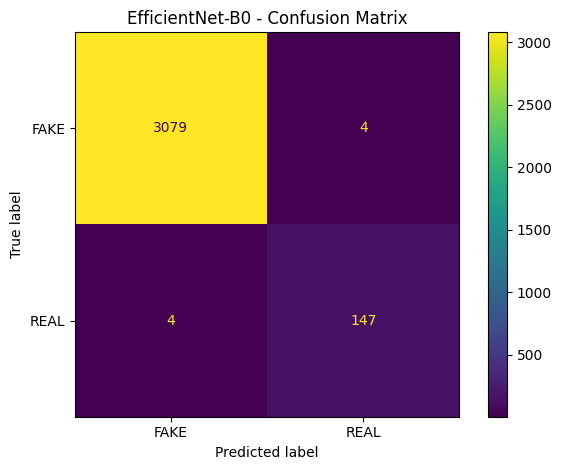

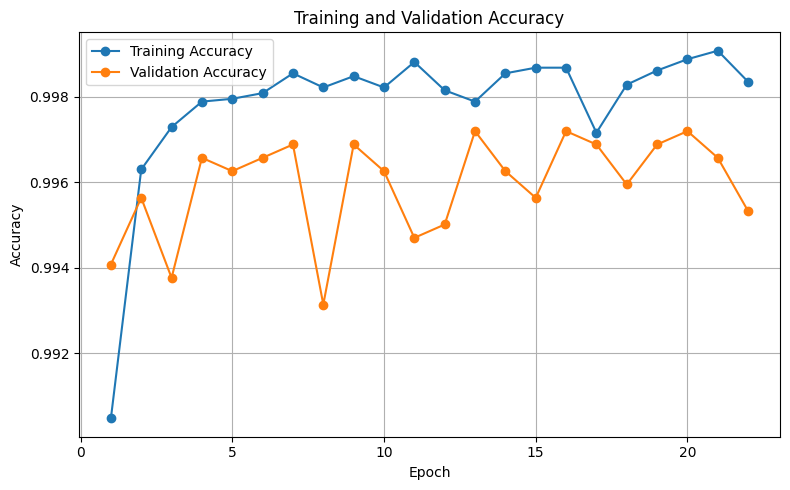

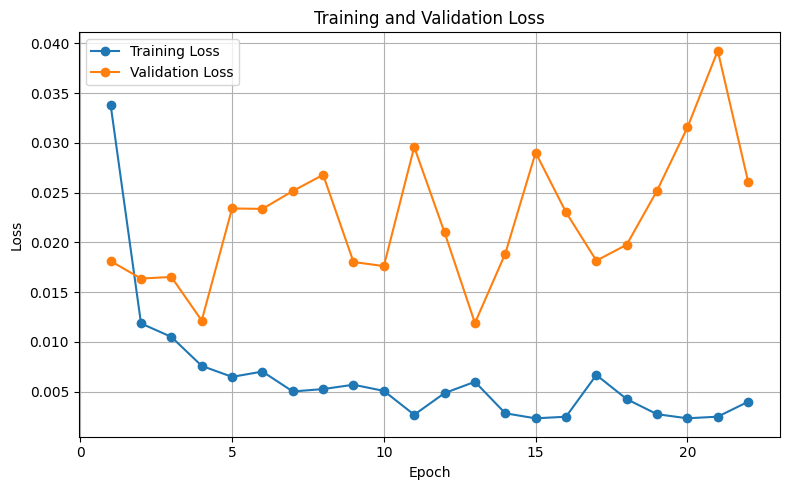

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# ==========================================
# 1. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"]
)
disp.plot(values_format="d")
plt.title("EfficientNet-B0 - Confusion Matrix")
plt.tight_layout()
plt.show()


# ==========================================
# 2. TRAINING vs VALIDATION ACCURACY
# ==========================================

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ==========================================
# 3. TRAINING vs VALIDATION LOSS
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()